In [23]:
import os
import json
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# imports for custom dataset class inheritance, 
# data loading with batching + weighted sampling
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools
from pycocotools import mask as mask_util # Import the pycocotools mask utility
from collections import Counter
from tqdm import tqdm

# --- 1. FILE PATHS AND CONFIGURATION ---
ANALYSIS_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\analysis"
PROCESSED_DATA_FOLDER = r"C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data"
JSON_FILE_PATH = os.path.join(PROCESSED_DATA_FOLDER, "json_2508", "patches_coco_with_features.json")
# Corrected the image folder to point to the 'patches_2508' subdirectory
IMAGE_FOLDER = os.path.join(PROCESSED_DATA_FOLDER, "patches_2508")

# Model configuration
# The classes are: 0: background, 1: other (id 0), 2: rbc (id 1), 3: cbc (id 2)
NUM_CLASSES = 4
BATCH_SIZE = 4
NUM_EPOCHS = 12
LEARNING_RATE = 0.005


### 
Sanity check before running

In [24]:
import json, os
from pycocotools import mask as mask_util

# 1) Load json and quick sanity
with open(JSON_FILE_PATH,'r') as f:
    coco = json.load(f)

print("images:", len(coco.get('images',[])))
print("annotations:", len(coco.get('annotations',[])))

# 2) Do a quick image-path existence test for a few samples
for img in coco['images'][:5]:
    p = os.path.join(IMAGE_FOLDER, img['file_name'])
    print(img['file_name'], "->", p, "exists?", os.path.isfile(p))

# 3) Check category ids (important)
cat_ids = sorted({ann['category_id'] for ann in coco['annotations']})
print("unique category_id values:", cat_ids)

# 4) Try decoding the first mask (RLE) to confirm segmentation format is compatible
ann = coco['annotations'][0]
if isinstance(ann.get('segmentation'), dict) and 'counts' in ann['segmentation']:
    rle = ann['segmentation']
    mask = mask_util.decode(rle)   # should produce np.ndarray of shape (H,W)
    print("decoded mask shape:", mask.shape, "mask dtype:", mask.dtype)
else:
    print("segmentation not RLE dict (check format).")


images: 772
annotations: 10860
patch_000000.png -> C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\patches_2508\patch_000000.png exists? True
patch_000001.png -> C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\patches_2508\patch_000001.png exists? True
patch_000002.png -> C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\patches_2508\patch_000002.png exists? True
patch_000003.png -> C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\patches_2508\patch_000003.png exists? True
patch_000004.png -> C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\processed data\patches_2508\patch_000004.png exists? True
unique category_id values: [0, 1, 2]
decoded mask shape: (256, 256) mask dtype: uint8


### create custom dataset
Purpose:

To provide a structured way to load image data and annotations for training and evaluating deep learning models (like Mask R-CNN in this case) on cell images with segmentation masks and class labels.
Key Functionalities:

- Initializes with image metadata, annotation data, image directory, and optional transforms.
- Builds a mapping from image IDs to their annotations for efficient lookup.
- Implements len to return the number of images.
- Provides get_labels_for_image to retrieve all class labels for a given image.
- Implements getitem to:
- Load an image and its annotations.
- Validate and clamp bounding boxes to image dimensions.
- Filter out invalid boxes and labels.
- Decode segmentation masks using pycocotools.
- Return image tensors and a target dictionary containing boxes, labels, masks, and image ID.
- Optionally apply transformations to the image.

In [25]:
# --- 2. CUSTOM PYTORCH DATASET ---
# We need a custom dataset to read the images and the COCO-style JSON annotations.
class CellDataset(Dataset):
    def __init__(self, image_info, annotations, image_dir, transforms=None):
        """
        Args:
            image_info (list): List of dictionaries, one for each image.
            annotations (list): List of all annotations from the JSON file.
            image_dir (string): Directory with all the images.
            transforms (callable, optional): Optional transform to be applied on a sample.
        """
        self.image_info = image_info
        self.annotations = annotations
        self.image_dir = image_dir
        self.transforms = transforms

        # Create a mapping from image_id to annotations
        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.image_info)

    def get_labels_for_image(self, idx):
        img_data = self.image_info[idx]
        img_id = img_data['id']
        anns = self.img_to_anns.get(img_id, [])
        labels = [ann['category_id'] + 1 for ann in anns]
        return labels


    def __getitem__(self, idx):
        # Get image info for the given index
        img_data = self.image_info[idx]
        # The file_name in JSON already contains 'patches\', so we just join with the base processed data folder
        img_path = os.path.join(PROCESSED_DATA_FOLDER, img_data['file_name'])
        # Use the base filename and always join with IMAGE_FOLDER so both old and new JSON formats work
        img_name = os.path.basename(img_data['file_name'])   # e.g. "patch_000025.png"
        img_path = os.path.join(IMAGE_FOLDER, img_name)      # e.g. ".../patches_2508/patch_000025.png"

        # Load image
        try:
            image = Image.open(img_path).convert("RGB")
            width, height = image.size
        except FileNotFoundError:
            print(f"Warning: Image not found at {img_path}. Skipping.")
            return None, None

        # Get all annotations for this image
        img_id = img_data['id']
        anns = self.img_to_anns.get(img_id, [])

        # Extract bounding boxes, labels, and masks
        boxes = []
        labels = []
        masks = []

        for ann in anns:
            # Bounding box [x, y, w, h] -> [x1, y1, x2, y2]
            xmin = ann['bbox'][0]
            ymin = ann['bbox'][1]
            xmax = xmin + ann['bbox'][2]
            ymax = ymin + ann['bbox'][3]

            # --- DATA VALIDATION TO PREVENT RUNTIME ERRORS ---
            # Clamp boxes to image dimensions to prevent out-of-bounds errors
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)

            # Check for valid bounding box dimensions after clamping.
            if xmax <= xmin or ymax <= ymin:
                continue

            # Check for valid category_id.
            # the +1 is because we have background as class 0 in the model!! 
            label = ann['category_id'] + 1
            if label >= NUM_CLASSES:
                continue
            # --- END VALIDATION ---

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

            # Masks
            # Use pycocotools to decode the RLE segmentation
            mask = mask_util.decode(ann['segmentation'])
            masks.append(mask)

        # If after filtering, there are no valid annotations, we still need to return tensors
        if not boxes:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
        else:
            # Convert to torch tensors
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)

        # Create the target dictionary
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = torch.tensor([img_id])

        # Apply transformations
        if self.transforms:
            # We need to convert PIL Image to tensor here
            to_tensor = torchvision.transforms.ToTensor()
            image = to_tensor(image)

        return image, target


### data prep 

In [26]:

# --- 3. DATA PREPARATION & WEIGHTED SAMPLING ---
# Load the JSON file
with open(JSON_FILE_PATH, 'r') as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']

# Split the data into training and testing sets (80/20 split)
train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

# Create datasets
train_dataset = CellDataset(train_imgs, annotations, IMAGE_FOLDER, transforms=True)
test_dataset = CellDataset(test_imgs, annotations, IMAGE_FOLDER, transforms=True)


# --- IMPLEMENT WEIGHTED SAMPLING ---
print("Calculating weights for sampling...")
# Define custom weights for each class. Give high weights to 'rbc' and 'cbc'.
# Labels are 1:other, 2:rbc, 3:cbc
class_sample_weights = {1: 0.2, 2: 1.0, 3: 1.0}

# Assign a weight to each sample in the training set
sample_weights = []
for i in tqdm(range(len(train_dataset))):
    labels = train_dataset.get_labels_for_image(i)
    if not labels:
        # If an image has no labels, give it a very low weight
        sample_weights.append(0.1)
        continue
    # The weight of the sample is the maximum weight of any label it contains
    max_weight = max(class_sample_weights.get(l, 0.1) for l in labels)
    sample_weights.append(max_weight)

# Create the sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


# Custom collate function to handle None values from missing images
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch))
    if not batch:
        return torch.tensor([]), torch.tensor([])
    return tuple(zip(*batch))

# Create data loaders
# IMPORTANT: When using a sampler, shuffle must be False.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

print(f"Training set has {len(train_dataset)} images.")
print(f"Test set has {len(test_dataset)} images.")


Calculating weights for sampling...


100%|██████████| 617/617 [00:00<00:00, 308485.58it/s]

Training set has 617 images.
Test set has 155 images.


### define and instantiate the model

In [27]:

# --- 4. MODEL DEFINITION ---
def get_model_instance_segmentation(num_classes):
    # Load a pre-trained Mask R-CNN model
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # Replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# Instantiate the model
model = get_model_instance_segmentation(NUM_CLASSES)
model.to(device)


Using device: cuda


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

### Start Training

In [28]:
# --- 5. TRAINING ---
# Construct an optimizer
NUM_EPOCHS = 12
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Starting model training with weighted sampling...")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for i, (images, targets) in enumerate(train_loader):
        if not images: continue # Skip empty batches

        valid_indices = [idx for idx, t in enumerate(targets) if t['boxes'].shape[0] > 0]
        if not valid_indices:
            continue

        images = [images[i] for i in valid_indices]
        targets = [targets[i] for i in valid_indices]

        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(losses):
            print(f"WARNING: non-finite loss at epoch {epoch+1}, batch {i}. Skipping batch.")
            continue

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        if i > 0 and i % 50 == 0:
            print(f"  Batch {i}/{len(train_loader)}, Loss: {losses.item():.4f}")


    lr_scheduler.step()
    print(f"Epoch #{epoch+1} loss: {epoch_loss/len(train_loader):.4f}")

print("Training finished.")

# Save the trained model
torch.save(model.state_dict(), os.path.join(ANALYSIS_FOLDER, 'feature_json_trained_maskrcnn.pth'))
print(f"Model saved to {os.path.join(ANALYSIS_FOLDER, 'feature_json_trained_maskrcnn.pth')}")

Starting model training with weighted sampling...
  Batch 50/155, Loss: 1.0075
  Batch 100/155, Loss: 0.8678
  Batch 150/155, Loss: 0.8377
Epoch #1 loss: 1.1986
  Batch 50/155, Loss: 0.9636
  Batch 100/155, Loss: 1.0562
  Batch 150/155, Loss: 0.8971
Epoch #2 loss: 0.9029
  Batch 50/155, Loss: 0.9430
  Batch 100/155, Loss: 0.7684
  Batch 150/155, Loss: 0.7824
Epoch #3 loss: 0.7941
  Batch 50/155, Loss: 0.6118
  Batch 100/155, Loss: 0.6421
  Batch 150/155, Loss: 0.5505
Epoch #4 loss: 0.6969
  Batch 50/155, Loss: 0.6308
  Batch 100/155, Loss: 0.5355
  Batch 150/155, Loss: 0.5164
Epoch #5 loss: 0.6511
  Batch 50/155, Loss: 0.5320
  Batch 100/155, Loss: 0.6766
  Batch 150/155, Loss: 0.5721
Epoch #6 loss: 0.6329
  Batch 50/155, Loss: 0.6244
  Batch 100/155, Loss: 0.5233
  Batch 150/155, Loss: 0.5384
Epoch #7 loss: 0.6042
  Batch 50/155, Loss: 0.6203
  Batch 100/155, Loss: 0.4449
  Batch 150/155, Loss: 0.5735
Epoch #8 loss: 0.6044
  Batch 50/155, Loss: 0.6701
  Batch 100/155, Loss: 0.6747
  B

### evaluate and visualise

C:\Users\shiva\AppData\Local\Temp\ipykernel_5052\172150081.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(ANALYSIS_FOLDER,


Visualizing predictions on test images...


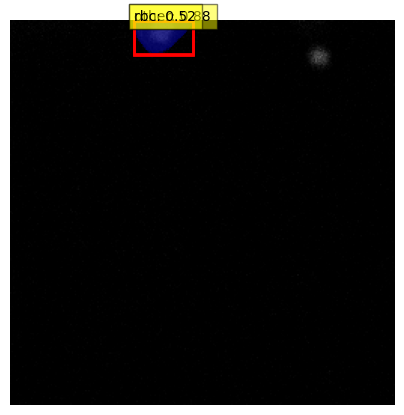

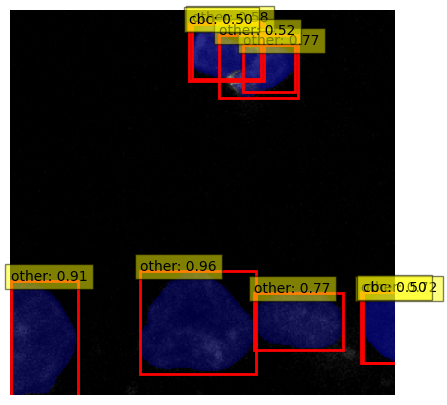

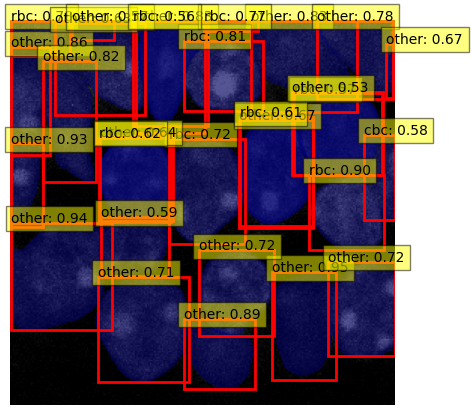

In [29]:
model.load_state_dict(torch.load(os.path.join(ANALYSIS_FOLDER,  'feature_json_trained_maskrcnn.pth')))
model.eval()

def visualize_prediction(image_tensor, prediction, threshold=0.5):
    """
    Visualizes the model's prediction on a single image.
    """
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(5, 5))
    ax.imshow(img)

    scores = prediction['scores'].cpu().detach().numpy()
    boxes = prediction['boxes'].cpu().detach().numpy()
    masks = prediction['masks'].cpu().detach().numpy()
    labels = prediction['labels'].cpu().detach().numpy()

    # Define a mapping from label index to name, based on your data creation script
    label_names = {1: 'other', 2: 'rbc', 3: 'cbc'}

    for i in range(len(scores)):
        if scores[i] > threshold:
            # Bounding box
            box = boxes[i]
            rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # Label
            label_idx = labels[i]
            label_name = label_names.get(label_idx, f'Unknown {label_idx}')
            plt.text(box[0], box[1], f'{label_name}: {scores[i]:.2f}', bbox=dict(facecolor='yellow', alpha=0.5))

            # Mask
            mask = masks[i, 0] > 0.5
            ax.imshow(np.ma.masked_where(mask == 0, mask), cmap='jet', alpha=0.5)

    plt.axis('off')
    plt.show()

# Visualize a few predictions from the test set
print("\nVisualizing predictions on test images...")
with torch.no_grad():
    for i in range(min(3, len(test_dataset))): # Visualize first 5 images
        img, _ = test_dataset[i]
        if img is None: continue
        img_tensor = img.to(device)
        prediction = model([img_tensor])
        visualize_prediction(img_tensor, prediction[0])


### show confusion matrix

In [32]:

# --- 7. CONFUSION MATRIX ---
print("\nGenerating Confusion Matrix...")
all_preds = []
all_labels = []

with torch.no_grad():
    for images, targets in test_loader:
        if not images: continue
        images = list(img.to(device) for img in images)

        outputs = model(images)

        for i in range(len(outputs)):
            # Get model predictions
            pred_labels = outputs[i]['labels'].cpu().numpy()
            pred_scores = outputs[i]['scores'].cpu().numpy()

            # Filter predictions by score
            preds = pred_labels[pred_scores > 0.5]

            # Get ground truth labels
            true_labels = targets[i]['labels'].cpu().numpy()

            # For simplicity, we'll take the most frequent prediction if any,
            # and the most frequent ground truth. A more advanced approach
            # would use IoU matching.
            if len(preds) > 0:
                # Use the label of the highest score prediction
                all_preds.append(preds[0])
            else:
                all_preds.append(0) # Predict background if no object detected

            if len(true_labels) > 0:
                all_labels.append(true_labels[0])
            else:
                all_labels.append(0) # Ground truth is background

# Compute confusion matrix
# CORRECTED: Updated labels and class_names for the confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])
class_names = ['Background', 'other', 'rbc', 'cbc']



Generating Confusion Matrix...


Confusion matrix, without normalization


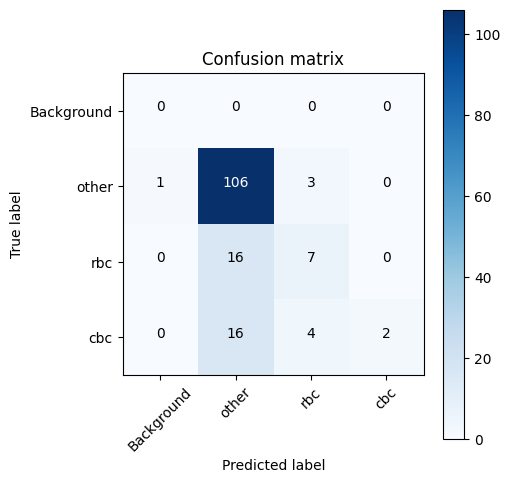

In [34]:

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Plotting the confusion matrix
plt.figure(figsize=(5,5))
plot_confusion_matrix(cm, class_names)